# 03 - Concentração e entrega

Case Olist | Tech Challenge Fase 1

### A pergunta

O notebook 02 encontrou duas coisas: o crescimento parou por falta de clientes, e 73% da receita vem de cinco
estados. Este notebook testa se as duas têm a mesma origem.

A pergunta importa porque as respostas levam a decisões opostas. Se o resto do país simplesmente não compra,
não há muito a fazer. Se compra pouco porque receber é lento e caro, existe um problema de operação, e
problema de operação se resolve com investimento.

### Como o atraso é medido

A data prometida vem sem hora na base e a data real vem com hora cheia. Comparar as duas diretamente
classifica como atrasado um pedido entregue no dia certo às 15h, o que afeta 1.292 pedidos e move o atraso da
base de 6,8% para 8,1%. A coluna `atrasou` vem do notebook 01 comparando apenas o dia.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../data/kpis', exist_ok=True)

fato_itens = pd.read_csv('../data/processed/fato_itens.csv')
pedidos = pd.read_csv('../data/processed/pedidos_tratados.csv')

for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    pedidos[col] = pd.to_datetime(pedidos[col])

In [2]:
receita = fato_itens[
    (fato_itens['mes'].between('2017-01', '2018-08')) &
    (~fato_itens['order_status'].isin(['canceled', 'unavailable']))
].copy()

entregues = pedidos[
    (pedidos['mes'].between('2017-01', '2018-08')) &
    (pedidos['order_status'] == 'delivered') &
    (pedidos['order_delivered_customer_date'].notna())
].copy()

print('itens de receita:', len(receita))
print('pedidos entregues:', len(entregues))
print('atraso no período:', round(entregues['atrasou'].mean() * 100, 2), '%')

itens de receita: 111752
pedidos entregues: 96203
atraso no período: 6.79 %


O recorte de receita é o mesmo do notebook 02. As métricas de entrega usam apenas pedidos entregues,
porque pedido que não chegou não tem tempo mensurável.

## Receita e tempo de entrega, lado a lado

In [3]:
receita_uf = receita.groupby('customer_state')['receita'].sum().reset_index()
receita_uf['pct_receita'] = receita_uf['receita'] / receita_uf['receita'].sum() * 100

entrega_uf = entregues.groupby('customer_state').agg(
    dias_entrega=('dias_entrega', 'mean'),
    pct_atraso=('atrasou', 'mean'),
    pedidos=('order_id', 'nunique'),
).reset_index()
entrega_uf['pct_atraso'] *= 100

uf = receita_uf.merge(entrega_uf, on='customer_state').sort_values('receita', ascending=False)
uf.to_csv('../data/kpis/kpi_entrega_estado.csv', index=False)

uf.head(10).round(2)

,customer_state,receita,pct_receita,dias_entrega,pct_atraso,pedidos
25,SP,5863232.66,37.38,8.27,4.50,40399
18,RJ,2105549.64,13.43,14.84,12.14,12310
10,MG,1837646.07,11.72,11.52,4.59,11319
22,RS,873634.76,5.57,14.81,6.10,5327
17,PR,791701.89,5.05,11.51,4.06,4903
4,BA,605913.32,3.86,18.87,12.17,3253
23,SC,605522.98,3.86,14.47,8.23,3537
6,DF,350127.10,2.23,12.48,5.69,2074
8,GO,339389.70,2.16,15.16,6.56,1950
7,ES,322013.89,2.05,15.32,10.74,1992


In [4]:
uf.sort_values('dias_entrega', ascending=False).head(8).round(2)

,customer_state,receita,pct_receita,dias_entrega,pct_atraso,pedidos
21,RR,9743.72,0.06,29.50,12.50,40
3,AP,16262.80,0.10,26.73,2.99,67
2,AM,27835.73,0.18,25.99,2.76,145
1,AL,96099.50,0.61,24.02,21.46,396
13,PA,216197.45,1.38,23.30,11.25,942
9,MA,149689.11,0.95,21.08,17.53,713
24,SE,72686.40,0.46,20.95,15.36,332
5,CE,272572.83,1.74,20.79,13.83,1273


In [5]:
top5 = uf.head(5)
resto = uf.tail(len(uf) - 5)

print('top 5 estados  |', round(top5['pct_receita'].sum(), 1), '% da receita |',
      round((top5['dias_entrega'] * top5['pedidos']).sum() / top5['pedidos'].sum(), 1), 'dias')
print('outros', len(resto), 'estados |', round(resto['pct_receita'].sum(), 1), '% da receita |',
      round((resto['dias_entrega'] * resto['pedidos']).sum() / resto['pedidos'].sum(), 1), 'dias')
print()
print('correlação entre dias de entrega e participação na receita:',
      round(uf['dias_entrega'].corr(uf['pct_receita']), 2))

top 5 estados  | 73.1 % da receita | 10.5 dias
outros 22 estados | 26.9 % da receita | 17.3 dias

correlação entre dias de entrega e participação na receita: -0.6


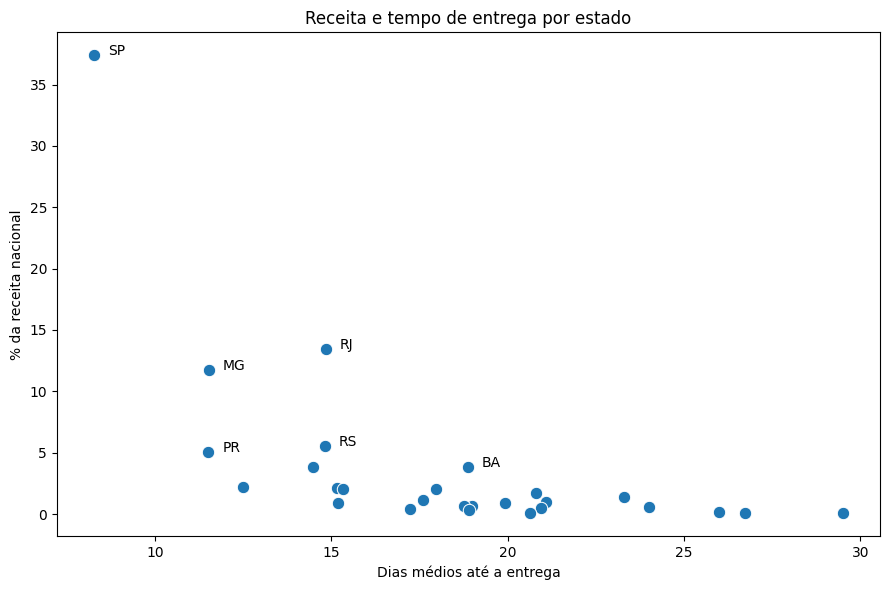

In [6]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=uf, x='dias_entrega', y='pct_receita', s=80)
for _, linha in uf.head(6).iterrows():
    plt.text(linha['dias_entrega'] + 0.4, linha['pct_receita'], linha['customer_state'], fontsize=10)

plt.title('Receita e tempo de entrega por estado')
plt.xlabel('Dias médios até a entrega')
plt.ylabel('% da receita nacional')
plt.tight_layout()
plt.savefig('../figures/chart_10_receita_x_entrega.png', dpi=150)
plt.show()

Os cinco estados que concentram 73% da receita recebem em 10,5 dias. Os outros 22, que dividem 27%,
esperam 17,3 dias. São Paulo é o mais rápido do país com 8,3 dias, e Roraima o mais lento com 29,5, três vezes
e meia mais.

A correlação entre demorar e vender menos é de -0,60.

Isso é correlação, não prova de causa. São Paulo também concentra população e renda, o que explica parte da
diferença. Mas a entrega é a parcela do problema que a empresa controla, e é o que torna o achado acionável.

In [7]:
# a correlacao acima trata cada estado igual. Sao Paulo tem 40 mil pedidos e Roraima tem 40,
# entao vale ver quanto ela muda quando o peso e o volume de pedidos
import numpy as np

def correlacao_ponderada(x, y, peso):
    mx, my = np.average(x, weights=peso), np.average(y, weights=peso)
    cov = np.average((x - mx) * (y - my), weights=peso)
    return cov / np.sqrt(np.average((x - mx) ** 2, weights=peso) *
                         np.average((y - my) ** 2, weights=peso))

print('pedidos: SP', int(uf.loc[uf['customer_state'] == 'SP', 'pedidos'].iloc[0]),
      '| RR', int(uf.loc[uf['customer_state'] == 'RR', 'pedidos'].iloc[0]))
print('correlação simples:  ', round(uf['pct_receita'].corr(uf['dias_entrega']), 2))
print('correlação ponderada:', round(correlacao_ponderada(uf['pct_receita'], uf['dias_entrega'], uf['pedidos']), 2))

pedidos: SP 40399 | RR 40
correlação simples:   -0.6
correlação ponderada: -0.86


A correlação simples trata cada estado igual, e os volumes são muito diferentes: São Paulo tem 40.399 pedidos
e Roraima tem 40. Ponderando pelo volume, a relação fica mais forte, não mais fraca. O -0,60 é a leitura
conservadora e é o número que usamos.

## Atrasar e demorar não são a mesma coisa

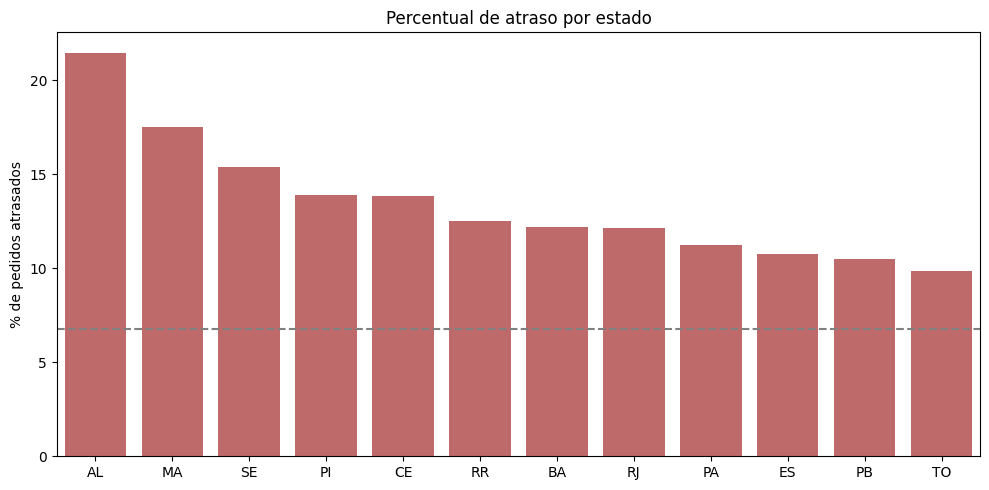

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=uf.sort_values('pct_atraso', ascending=False).head(12),
            x='customer_state', y='pct_atraso', color='indianred')
plt.axhline(entregues['atrasou'].mean() * 100, color='gray', linestyle='--')
plt.title('Percentual de atraso por estado')
plt.xlabel('')
plt.ylabel('% de pedidos atrasados')
plt.tight_layout()
plt.savefig('../figures/chart_11_atraso_estado.png', dpi=150)
plt.show()

In [9]:
uf[uf['customer_state'].isin(['SP', 'AL', 'MA', 'AP', 'RR'])][
    ['customer_state', 'pct_receita', 'dias_entrega', 'pct_atraso']].round(2)

,customer_state,pct_receita,dias_entrega,pct_atraso
25,SP,37.38,8.27,4.50
9,MA,0.95,21.08,17.53
1,AL,0.61,24.02,21.46
3,AP,0.10,26.73,2.99
21,RR,0.06,29.50,12.50


Alagoas entrega em 24 dias e atrasa 21,5% das vezes. Roraima demora mais, 29,5 dias, e atrasa 12,5%.
Amapá leva 26,7 dias e atrasa apenas 3%.

Atraso é entregar depois do prometido, não entregar devagar. Um estado distante pode ter zero atraso se o
prazo informado ao cliente já considerar a distância.

Onde o atraso é alto sem que o tempo seja o pior, como em Alagoas, o problema está na promessa e não na
operação. Recalibrar prazo é mais rápido e mais barato do que mudar logística.

## O custo, não só o tempo

In [10]:
receita['razao_item'] = receita['freight_value'] / receita['price']

frete_uf = receita.groupby('customer_state').agg(
    produto=('price', 'sum'), frete=('freight_value', 'sum'),
    media_das_razoes=('razao_item', 'mean'),
).reset_index()

frete_uf['agregado'] = frete_uf['frete'] / frete_uf['produto'] * 100
frete_uf['media_das_razoes'] *= 100
frete_uf.to_csv('../data/kpis/kpi_frete_estado.csv', index=False)

frete_uf.sort_values('agregado', ascending=False)[
    ['customer_state', 'agregado', 'media_das_razoes']].head(8).round(1)

,customer_state,agregado,media_das_razoes
21,RR,27.8,58.0
9,MA,26.2,55.0
20,RO,24.7,59.5
2,AM,24.5,49.8
16,PI,24.4,50.1
24,SE,24.0,46.6
26,TO,23.7,50.1
0,AC,23.1,51.2


In [11]:
for estado in ['SP', 'RJ', 'MG', 'BA', 'MA', 'RR']:
    linha = frete_uf[frete_uf['customer_state'] == estado].iloc[0]
    print(estado, '| frete sobre produto:', round(linha['agregado'], 1), '%')

SP | frete sobre produto: 13.8 %
RJ | frete sobre produto: 16.8 %
MG | frete sobre produto: 17.1 %
BA | frete sobre produto: 19.7 %
MA | frete sobre produto: 26.2 %
RR | frete sobre produto: 27.8 %


Em São Paulo o frete equivale a 13,8% do valor do produto. No Maranhão e em Roraima passa de 26%.

As duas colunas da tabela acima medem a mesma coisa por métodos diferentes, e a diferença é grande o
suficiente para mudar a conclusão. O agregado soma todo o frete e divide pela soma dos produtos, respondendo
quanto se paga de frete a cada R$ 100 de produto. A média das razões calcula a proporção item a item e tira a
média, o que resulta em 55,0% no Maranhão e 58,0% em Roraima porque um item de R$ 10 com frete de R$ 15 conta
como 150% e pesa igual a uma venda grande.

Usamos o agregado. Registramos o outro método porque é fácil chegar nele sem perceber a distorção.

Somando tempo e custo: comprar fora do Sudeste demora quase o dobro e custa quase o dobro de frete.

## O atraso afasta o cliente?

Esta é a pergunta que liga a entrega ao achado do notebook 02. Se quem tem má experiência não volta, a
logística deixa de ser um problema de satisfação e passa a ser um problema de receita.

Comparamos clientes pela primeira compra: os que receberam no prazo e os que receberam com atraso.

In [12]:
p = pedidos[~pedidos['order_status'].isin(['canceled', 'unavailable'])].copy()
p = p.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
p['ordem'] = p.groupby('customer_unique_id').cumcount() + 1

total_por_cliente = p.groupby('customer_unique_id')['order_id'].count().rename('total_pedidos')

primeira = p[p['ordem'] == 1].merge(total_por_cliente, on='customer_unique_id')
primeira = primeira[(primeira['order_status'] == 'delivered') &
                    (primeira['order_delivered_customer_date'].notna())].copy()
primeira['voltou'] = primeira['total_pedidos'] > 1

print('clientes com primeira compra entregue:', len(primeira))
print('recompra geral:', round(primeira['voltou'].mean() * 100, 2), '%')

clientes com primeira compra entregue: 93290
recompra geral: 3.02 %


Recompra aqui significa ter mais de um pedido não cancelado e não indisponível, não necessariamente
uma segunda compra entregue. Um cliente com a primeira compra entregue e uma segunda ainda em trânsito já
conta como recompra. O critério é intencionalmente permissivo: exigir que a segunda compra também
estivesse entregue reduziria a amostra e adiantaria a janela de corte sem mudar a direção do achado.

Quem comprou pela primeira vez em agosto de 2018 quase não teve tempo de voltar, porque a base termina
ali. Limitamos a quem comprou até fevereiro de 2018, garantindo pelo menos seis meses de janela para todos.

In [13]:
janela = primeira[primeira['order_purchase_timestamp'] < '2018-03-01']

comparacao = janela.groupby('atrasou').agg(
    clientes=('customer_unique_id', 'count'), recompra=('voltou', 'mean'),
).reset_index()
comparacao['recompra_pct'] = (comparacao['recompra'] * 100).round(2)
comparacao.to_csv('../data/kpis/kpi_recompra_atraso.csv', index=False)

no_prazo = comparacao[~comparacao['atrasou']]['recompra'].values[0]
atrasado = comparacao[comparacao['atrasou']]['recompra'].values[0]

print(comparacao[['atrasou', 'clientes', 'recompra_pct']].to_string(index=False))
print()
print('diferença absoluta:', round((no_prazo - atrasado) * 100, 2), 'pontos percentuais')
print('queda relativa:', round((atrasado / no_prazo - 1) * 100, 1), '%')

 atrasou  clientes  recompra_pct
   False     51813          4.08
    True      3674          3.16

diferença absoluta: 0.92 pontos percentuais
queda relativa: -22.6 %


In [14]:
tabela = pd.crosstab(janela['atrasou'], janela['voltou'])
chi2, p_valor, _, _ = chi2_contingency(tabela)

print(tabela)
print()
print('p-valor:', round(p_valor, 5))

voltou   False  True 
atrasou              
False    49700   2113
True      3558    116

p-valor: 0.00687


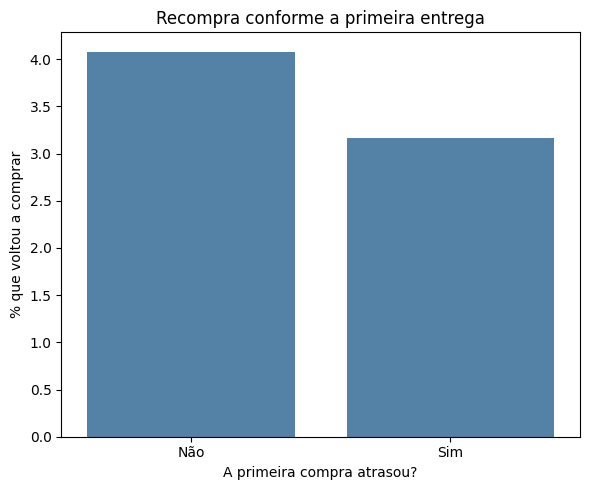

In [15]:
plt.figure(figsize=(6, 5))
sns.barplot(data=comparacao, x='atrasou', y='recompra_pct', color='steelblue')
plt.title('Recompra conforme a primeira entrega')
plt.xlabel('A primeira compra atrasou?')
plt.ylabel('% que voltou a comprar')
plt.xticks([0, 1], ['Não', 'Sim'])
plt.tight_layout()
plt.savefig('../figures/chart_12_recompra_atraso.png', dpi=150)
plt.show()

Clientes cuja primeira compra chegou no prazo voltam em 4,08% dos casos. Com atraso, 3,16%. Uma queda de
22,6%, e o teste de qui-quadrado devolve p-valor de 0,007, o que descarta acaso.

O tamanho do efeito precisa ser dito com clareza: a diferença absoluta é de 0,92 ponto percentual. Mesmo com
entrega no prazo, cerca de 96% dos clientes não voltam.

O atraso agrava um problema de retenção que já existe por outro motivo. Isso tem consequência prática para
estimativas de perda: multiplicar clientes insatisfeitos pelo ticket médio cheio assume que todos teriam
voltado, e os dados não sustentam essa premissa. A conta correta usa a diferença entre os dois grupos.

## Achados

**1. A entrega explica parte da concentração geográfica.** Os cinco estados com 73% da receita recebem em 10,5
dias, os outros 22 esperam 17,3, e a correlação entre demora e participação na receita é de -0,60. É
correlação e não prova de causa, mas é a parcela do problema que a empresa controla.

**2. Não é só o tempo, é o custo.** O frete representa 13,8% do valor do produto em São Paulo e mais de 26% no
Maranhão e em Roraima. Fora do Sudeste, comprar demora quase o dobro e custa quase o dobro de frete.

**3. Atrasar não é demorar.** Alagoas atrasa 21,5% entregando em 24 dias, enquanto Roraima atrasa 12,5%
entregando em 29,5. Onde a promessa está mal calibrada, corrigir o prazo informado é mais barato que mudar a
operação.

**4. O atraso reduz a recompra, mas pouco.** Queda de 22,6% em termos relativos e estatisticamente
significativa, porém apenas 0,92 ponto percentual em absoluto. Resolver a entrega é necessário e não é
suficiente para criar uma base fiel.

### Fechando com o notebook 02

O crescimento parou por falta de clientes, e conquistar cliente é mais difícil justamente onde entregar é
lento e caro. Investimento em logística regional ataca os dois problemas ao mesmo tempo: abre mercado onde
existe espaço e reduz a perda de quem já comprou.

Mas como o atraso explica menos de um ponto percentual da recompra, a retenção precisa de uma frente própria,
que a logística sozinha não resolve.